In [2]:

import os
from google.colab import userdata

os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

print("Kaggle API token loaded successfully!")


Kaggle API token loaded successfully!


In [3]:

!pip install -q kaggle

!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset --unzip -p /content/brain_tumor_mri


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:06<00:00, 24.0MB/s]



In [5]:

import os

print("Files in /content:")
print(os.listdir("/content"))


Files in /content:
['.config', 'brain_tumor_mri', 'sample_data']


In [6]:

import os

dataset_path = "/content/brain_tumor_mri"

print("Folder contents:")
print(os.listdir(dataset_path))


Folder contents:
['Testing', 'Training']


In [7]:

import os
import pandas as pd

dataset_path = "/content/brain_tumor_mri"
image_extensions = (".jpg", ".jpeg", ".png", ".bmp")

data = []

for split in ["Training", "Testing"]:
    split_path = os.path.join(dataset_path, split)

    for category in os.listdir(split_path):
        category_path = os.path.join(split_path, category)

        if os.path.isdir(category_path):
            count = sum(
                1 for file in os.listdir(category_path)
                if file.lower().endswith(image_extensions)
            )

            data.append({
                "Dataset": split,
                "Category": category,
                "Images": count
            })

df = pd.DataFrame(data)

print("BRAIN TUMOR MRI DATASET ANALYSIS")
print(df.to_string(index=False))
print("\nTotal images:", df["Images"].sum())


BRAIN TUMOR MRI DATASET ANALYSIS
 Dataset   Category  Images
Training  pituitary    1400
Training meningioma    1400
Training     glioma    1400
Training    notumor    1400
 Testing  pituitary     400
 Testing meningioma     400
 Testing     glioma     400
 Testing    notumor     400

Total images: 7200


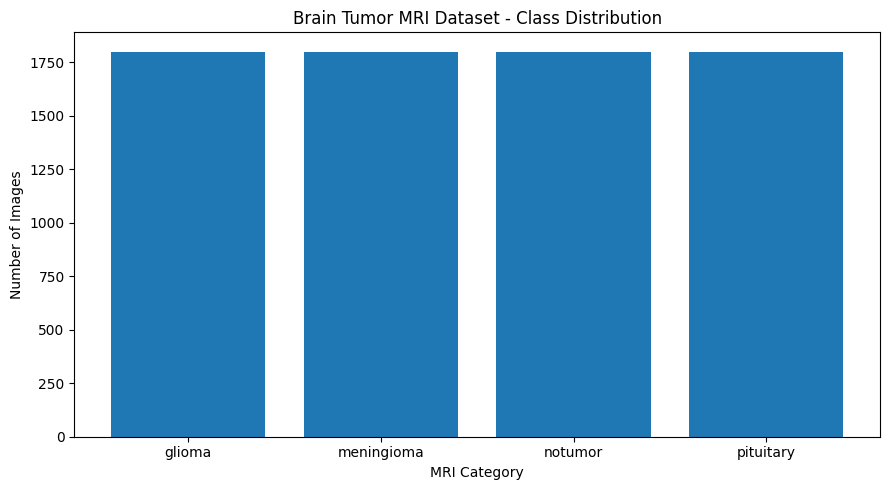

In [8]:

import matplotlib.pyplot as plt

class_counts = df.groupby("Category")["Images"].sum()

plt.figure(figsize=(9, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Brain Tumor MRI Dataset - Class Distribution")
plt.xlabel("MRI Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300)
plt.show()


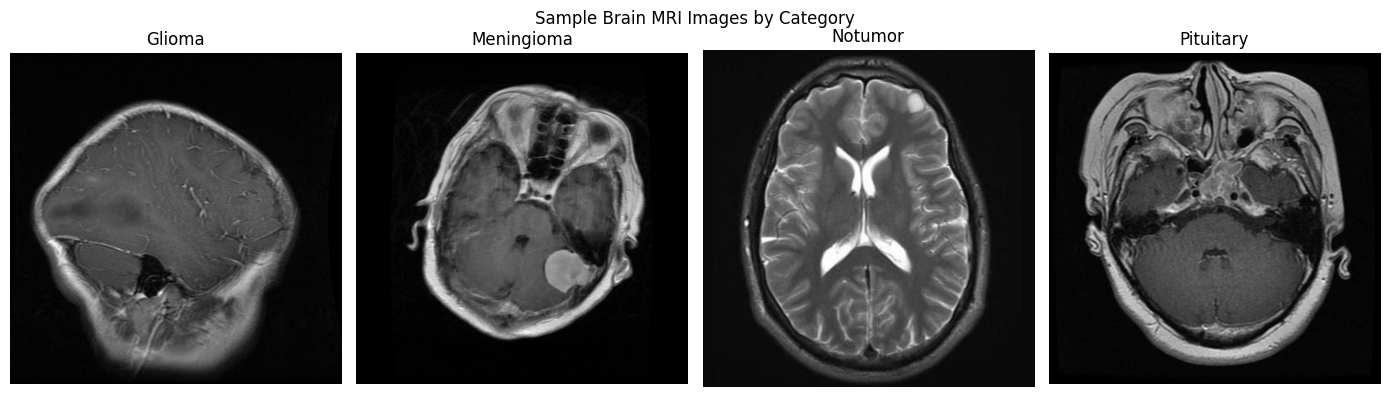

In [9]:

import os
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/content/brain_tumor_mri/Training"
categories = ["glioma", "meningioma", "notumor", "pituitary"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, category in zip(axes, categories):
    folder = os.path.join(dataset_path, category)
    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    img = Image.open(os.path.join(folder, images[0]))
    ax.imshow(img, cmap="gray")
    ax.set_title(category.capitalize())
    ax.axis("off")

plt.suptitle("Sample Brain MRI Images by Category")
plt.tight_layout()
plt.savefig("sample_mri_images.png", dpi=300)
plt.show()
